<a href="https://colab.research.google.com/github/Tolegithub7/ml_labs/blob/main/PythonAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This lab exercise involves creating a graph library, implementing search algorithms, analyzing their performance, and designing a robotic simulator.

In [24]:
# Construct Graph

import csv

class Graph:
    def __init__(self):
        self.nodes = set()
        self.edges = {}
        self.distances = {}

    def add_node(self, value):
        self.nodes.add(value)
        self.edges[value] = []

    def add_edge(self, from_node, to_node, distance):
        if from_node in self.nodes and to_node in self.nodes:
            self.edges[from_node].append(to_node)
            self.edges[to_node].append(from_node)
            self.distances[(from_node, to_node)] = distance
            self.distances[(to_node, from_node)] = distance

    def remove_node(self, value):
        if value in self.nodes:
            self.nodes.remove(value)
            self.edges.pop(value, None)
            self.distances = {k: v for k, v in self.distances.items() if value not in k}
            for edge_list in self.edges.values():
                if value in edge_list:
                    edge_list.remove(value)

    def remove_edge(self, from_node, to_node):
        if from_node in self.nodes and to_node in self.nodes:
            if to_node in self.edges[from_node]:
                self.edges[from_node].remove(to_node)
            if from_node in self.edges[to_node]:
                self.edges[to_node].remove(from_node)
            self.distances.pop((from_node, to_node), None)
            self.distances.pop((to_node, from_node), None)

# Load Romania map coordinates from CSV file
def load_romania_map(filename):
    graph = Graph()
    with open(filename, mode='r') as infile:
        reader = csv.reader(infile)
        next(reader)  # Skip header
        for row in reader:
            city = row[0]
            graph.add_node(city)
    return graph

# Example usage
romania_graph = load_romania_map('romania_coordinates.csv')
romania_graph.add_edge('Arad', 'Zerind', 75)
romania_graph.add_edge('Arad', 'Timisoara', 118)
romania_graph.add_edge('Zerind', 'Oradea', 71)
romania_graph.add_edge('Timisoara', 'Lugoj', 111)
romania_graph.add_edge('Lugoj', 'Mehadia', 70)
romania_graph.add_edge('Mehadia', 'Drobeta', 75)
romania_graph.add_edge('Drobeta', 'Craiova', 120)
romania_graph.add_edge('Craiova', 'Pitesti', 138)
romania_graph.add_edge('Pitesti', 'Bucharest', 101)
romania_graph.add_edge('Bucharest', 'Giurgiu', 90)
romania_graph.add_edge('Bucharest', 'Urziceni', 85)
romania_graph.add_edge('Urziceni', 'Hirsova', 98)
romania_graph.add_edge('Hirsova', 'Eforie', 86)
romania_graph.add_edge('Urziceni', 'Vaslui', 142)
romania_graph.add_edge('Vaslui', 'Iasi', 92)
romania_graph.add_edge('Iasi', 'Neamt', 87)
romania_graph.add_edge('Arad', 'Sibiu', 140)
romania_graph.add_edge('Sibiu', 'Fagaras', 99)
romania_graph.add_edge('Sibiu', 'Rimnicu Vilcea', 80)
romania_graph.add_edge('Rimnicu Vilcea', 'Pitesti', 97)
romania_graph.add_edge('Rimnicu Vilcea', 'Craiova', 146)
romania_graph.add_edge('Fagaras', 'Bucharest', 211)

In [25]:
class Node:
    def __init__(self, name):
        self.name = name
        self.adjacency_list = []

    def add_edge(self, neighbor, distance):
        self.adjacency_list.append((neighbor, distance))

# Example usage
arad = Node('Arad')
zerind = Node('Zerind')
arad.add_edge(zerind, 75)

print(f"Node: {arad.name}, Edges: {[(neighbor.name, distance) for neighbor, distance in arad.adjacency_list]}")

Node: Arad, Edges: [('Zerind', 75)]


In [26]:
# Insert and Delete Edges and Nodes

class Graph:
    def __init__(self):
        self.nodes = set()
        self.edges = {}
        self.distances = {}

    def add_node(self, value):
        self.nodes.add(value)
        self.edges[value] = []

    def add_edge(self, from_node, to_node, distance):
        if from_node in self.nodes and to_node in self.nodes:
            self.edges[from_node].append(to_node)
            self.edges[to_node].append(from_node)
            self.distances[(from_node, to_node)] = distance
            self.distances[(to_node, from_node)] = distance

    def remove_node(self, value):
        if value in self.nodes:
            self.nodes.remove(value)
            self.edges.pop(value, None)
            self.distances = {k: v for k, v in self.distances.items() if value not in k}
            for edge_list in self.edges.values():
                if value in edge_list:
                    edge_list.remove(value)

    def remove_edge(self, from_node, to_node):
        if from_node in self.nodes and to_node in self.nodes:
            if to_node in self.edges[from_node]:
                self.edges[from_node].remove(to_node)
            if from_node in self.edges[to_node]:
                self.edges[to_node].remove(from_node)
            self.distances.pop((from_node, to_node), None)
            self.distances.pop((to_node, from_node), None)

# Example usage
romania_graph = Graph()
romania_graph.add_node('Arad')
romania_graph.add_node('Zerind')
romania_graph.add_edge('Arad', 'Zerind', 75)

print(f"Nodes: {romania_graph.nodes}")
print(f"Edges: {romania_graph.edges}")
print(f"Distances: {romania_graph.distances}")

romania_graph.remove_edge('Arad', 'Zerind')
print(f"Edges after removing edge: {romania_graph.edges}")

romania_graph.remove_node('Zerind')
print(f"Nodes after removing node: {romania_graph.nodes}")
print(f"Edges after removing node: {romania_graph.edges}")

Nodes: {'Zerind', 'Arad'}
Edges: {'Arad': ['Zerind'], 'Zerind': ['Arad']}
Distances: {('Arad', 'Zerind'): 75, ('Zerind', 'Arad'): 75}
Edges after removing edge: {'Arad': [], 'Zerind': []}
Nodes after removing node: {'Arad'}
Edges after removing node: {'Arad': []}


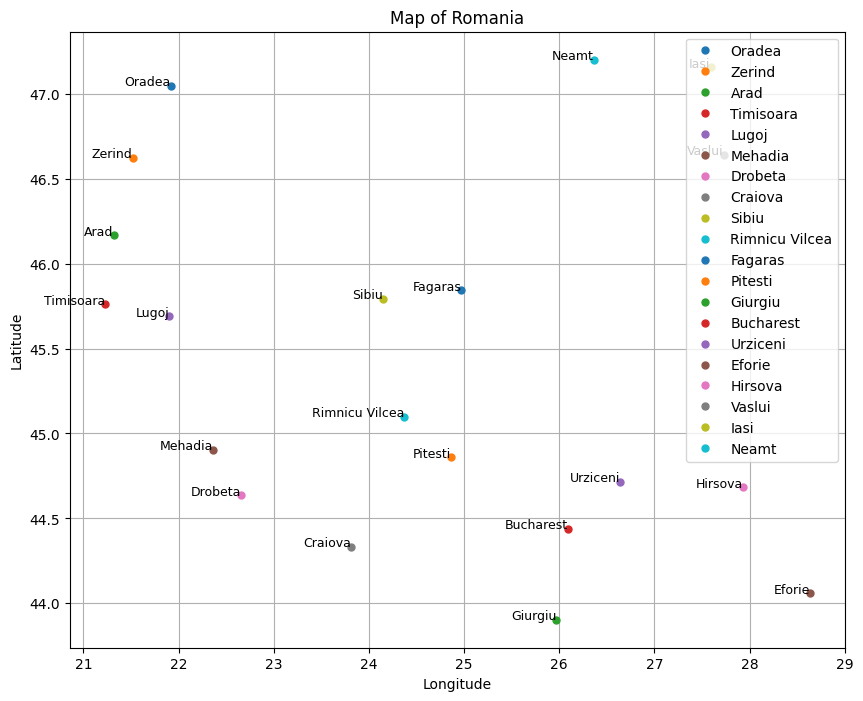

In [27]:
# Map of Romania

import csv
import matplotlib.pyplot as plt

# Load Romania map coordinates from CSV file
def load_romania_coordinates(filename):
    coordinates = {}
    with open(filename, mode='r') as infile:
        reader = csv.reader(infile)
        next(reader)  # Skip header
        for row in reader:
            city = row[0]
            latitude = float(row[1])
            longitude = float(row[2])
            coordinates[city] = (latitude, longitude)
    return coordinates

# Plot Romania map
def plot_romania_map(coordinates):
    plt.figure(figsize=(10, 8))
    for city, (lat, lon) in coordinates.items():
        plt.plot(lon, lat, 'o', markersize=5, label=city)
        plt.text(lon, lat, city, fontsize=9, ha='right')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Map of Romania')
    plt.grid(True)
    plt.legend(loc='best')
    plt.show()

# Example usage
romania_coordinates = load_romania_coordinates('romania_coordinates.csv')
plot_romania_map(romania_coordinates)

In [32]:
# Implementation of Search Algorithms

import heapq
import random
import math
import time

# Breadth-First Search (BFS)
def bfs(graph, start, goal):
    visited = set()
    queue = [(start, [start])]
    while queue:
        (vertex, path) = queue.pop(0)
        if vertex in visited:
            continue
        visited.add(vertex)
        for neighbor in graph[vertex]:
            if neighbor == goal:
                return path + [neighbor]
            else:
                queue.append((neighbor, path + [neighbor]))
    return None

# Depth-First Search (DFS)
def dfs(graph, start, goal):
    visited = set()
    stack = [(start, [start])]
    while stack:
        (vertex, path) = stack.pop()
        if vertex in visited:
            continue
        visited.add(vertex)
        for neighbor in graph[vertex]:
            if neighbor == goal:
                return path + [neighbor]
            else:
                stack.append((neighbor, path + [neighbor]))
    return None

# Uniform Cost Search (UCS)
def ucs(graph, distances, start, goal):
    priority_queue = [(0, start, [start])]  # (cost, node, path)
    visited = set()

    while priority_queue:
        cost, current, path = heapq.heappop(priority_queue)
        if current in visited:
            continue
        visited.add(current)

        if current == goal:
            return path, cost

        for neighbor in graph[current]:
            if neighbor not in visited:
                total_cost = cost + distances.get((current, neighbor), float('inf'))
                heapq.heappush(priority_queue, (total_cost, neighbor, path + [neighbor]))

    return None, float('inf')


# Iterative Deepening Search (IDS)
def ids(graph, start, goal, max_depth):
    def dls(node, goal, depth, path):
        if depth == 0 and node == goal:
            return path
        if depth > 0:
            for neighbor in graph[node]:
                result = dls(neighbor, goal, depth - 1, path + [neighbor])
                if result is not None:
                    return result
        return None

    for depth in range(max_depth):
        result = dls(start, goal, depth, [start])
        if result is not None:
            return result
    return None

# Bidirectional Search
def bidirectional_search(graph, start, goal):
    if start == goal:
        return [start]

    front_visited = {start: [start]}
    back_visited = {goal: [goal]}

    front_queue = [start]
    back_queue = [goal]

    while front_queue and back_queue:
        if front_queue:
            current = front_queue.pop(0)
            for neighbor in graph[current]:
                if neighbor not in front_visited:
                    front_visited[neighbor] = front_visited[current] + [neighbor]
                    front_queue.append(neighbor)
                    if neighbor in back_visited:
                        return front_visited[neighbor] + back_visited[neighbor][::-1][1:]

        if back_queue:
            current = back_queue.pop(0)
            for neighbor in graph[current]:
                if neighbor not in back_visited:
                    back_visited[neighbor] = back_visited[current] + [neighbor]
                    back_queue.append(neighbor)
                    if neighbor in front_visited:
                        return front_visited[neighbor] + back_visited[neighbor][::-1][1:]

    return None

# Greedy Search
def greedy_search(graph, start, goal, coordinates):
    def heuristic(node, goal):
        (x1, y1) = coordinates[node]
        (x2, y2) = coordinates[goal]
        return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

    visited = set()
    queue = [(heuristic(start, goal), start, [start])]
    while queue:
        (h, vertex, path) = heapq.heappop(queue)
        if vertex in visited:
            continue
        visited.add(vertex)
        if vertex == goal:
            return path
        for neighbor in graph[vertex]:
            if neighbor not in visited:
                heapq.heappush(queue, (heuristic(neighbor, goal), neighbor, path + [neighbor]))
    return None

# A* Search
def a_star_search(graph, start, goal, coordinates):
    def heuristic(node, goal):
        (x1, y1) = coordinates[node]
        (x2, y2) = coordinates[goal]
        return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

    visited = set()
    queue = [(0 + heuristic(start, goal), 0, start, [start])]
    while queue:
        (f, cost, vertex, path) = heapq.heappop(queue)
        if vertex in visited:
            continue
        visited.add(vertex)
        if vertex == goal:
            return path
        for neighbor in graph[vertex]:
            if neighbor not in visited:
                total_cost = cost + romania_distances[(vertex, neighbor)]
                heapq.heappush(queue, (total_cost + heuristic(neighbor, goal), total_cost, neighbor, path + [neighbor]))
    return None

# Simulated Annealing Search
def simulated_annealing(graph, start, goal, coordinates):
    def heuristic(node, goal):
        (x1, y1) = coordinates[node]
        (x2, y2) = coordinates[goal]
        return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

    current = start
    current_path = [start]
    current_cost = heuristic(start, goal)
    temperature = 1.0
    cooling_rate = 0.003

    while temperature > 0.01:
        neighbors = graph[current]
        if not neighbors:
            break
        next_node = random.choice(neighbors)
        next_cost = heuristic(next_node, goal)
        delta_cost = next_cost - current_cost

        if delta_cost < 0 or random.uniform(0, 1) < math.exp(-delta_cost / temperature):
            current = next_node
            current_path.append(next_node)
            current_cost = next_cost

        temperature *= 1 - cooling_rate

    if current == goal:
        return current_path
    return None

# Define the Romania graph
romania_graph = {
    'Arad': ['Zerind', 'Timisoara', 'Sibiu'],
    'Zerind': ['Arad', 'Oradea'],
    'Oradea': ['Zerind', 'Sibiu'],
    'Timisoara': ['Arad', 'Lugoj'],
    'Lugoj': ['Timisoara', 'Mehadia'],
    'Mehadia': ['Lugoj', 'Drobeta'],
    'Drobeta': ['Mehadia', 'Craiova'],
    'Craiova': ['Drobeta', 'Rimnicu Vilcea', 'Pitesti'],
    'Sibiu': ['Arad', 'Oradea', 'Fagaras', 'Rimnicu Vilcea'],
    'Rimnicu Vilcea': ['Sibiu', 'Craiova', 'Pitesti'],
    'Fagaras': ['Sibiu', 'Bucharest'],
    'Pitesti': ['Rimnicu Vilcea', 'Craiova', 'Bucharest'],
    'Bucharest': ['Fagaras', 'Pitesti', 'Giurgiu', 'Urziceni'],
    'Giurgiu': ['Bucharest'],
    'Urziceni': ['Bucharest', 'Hirsova', 'Vaslui'],
    'Hirsova': ['Urziceni', 'Eforie'],
    'Eforie': ['Hirsova'],
    'Vaslui': ['Urziceni', 'Iasi'],
    'Iasi': ['Vaslui', 'Neamt'],
    'Neamt': ['Iasi']
}

# Define the distances between cities
romania_distances = {
    ('Arad', 'Zerind'): 75, ('Zerind', 'Arad'): 75,
    ('Arad', 'Timisoara'): 118, ('Timisoara', 'Arad'): 118,
    ('Arad', 'Sibiu'): 140, ('Sibiu', 'Arad'): 140,
    ('Zerind', 'Oradea'): 71, ('Oradea', 'Zerind'): 71,
    ('Oradea', 'Sibiu'): 151, ('Sibiu', 'Oradea'): 151,
    ('Timisoara', 'Lugoj'): 111, ('Lugoj', 'Timisoara'): 111,
    ('Lugoj', 'Mehadia'): 70, ('Mehadia', 'Lugoj'): 70,
    ('Mehadia', 'Drobeta'): 75, ('Drobeta', 'Mehadia'): 75,
    ('Drobeta', 'Craiova'): 120, ('Craiova', 'Drobeta'): 120,
    ('Craiova', 'Rimnicu Vilcea'): 146, ('Rimnicu Vilcea', 'Craiova'): 146,
    ('Craiova', 'Pitesti'): 138, ('Pitesti', 'Craiova'): 138,
    ('Sibiu', 'Fagaras'): 99, ('Fagaras', 'Sibiu'): 99,
    ('Sibiu', 'Rimnicu Vilcea'): 80, ('Rimnicu Vilcea', 'Sibiu'): 80,
    ('Rimnicu Vilcea', 'Pitesti'): 97, ('Pitesti', 'Rimnicu Vilcea'): 97,
    ('Fagaras', 'Bucharest'): 211, ('Bucharest', 'Fagaras'): 211,
    ('Pitesti', 'Bucharest'): 101, ('Bucharest', 'Pitesti'): 101,
    ('Bucharest', 'Giurgiu'): 90, ('Giurgiu', 'Bucharest'): 90,
    ('Bucharest', 'Urziceni'): 85, ('Urziceni', 'Bucharest'): 85,
    ('Urziceni', 'Hirsova'): 98, ('Hirsova', 'Urziceni'): 98,
    ('Hirsova', 'Eforie'): 86, ('Eforie', 'Hirsova'): 86,
    ('Urziceni', 'Vaslui'): 142, ('Vaslui', 'Urziceni'): 142,
    ('Vaslui', 'Iasi'): 92, ('Iasi', 'Vaslui'): 92,
    ('Iasi', 'Neamt'): 87, ('Neamt', 'Iasi'): 87
}

# Define the coordinates of each city
romania_coordinates = {
    'Arad': (46.1833, 21.3167), 'Zerind': (46.6167, 21.5167), 'Oradea': (47.0667, 21.9333),
    'Timisoara': (45.7597, 21.2300), 'Lugoj': (45.6886, 21.9031), 'Mehadia': (44.9048, 22.3645),
    'Drobeta': (44.6369, 22.6597), 'Craiova': (44.3302, 23.7949), 'Sibiu': (45.7971, 24.1519),
    'Rimnicu Vilcea': (45.1000, 24.3667), 'Fagaras': (45.8416, 24.9731), 'Pitesti': (44.8565, 24.8692),
    'Bucharest': (44.4328, 26.1043), 'Giurgiu': (43.9000, 25.9667), 'Urziceni': (44.7167, 26.6333),
    'Hirsova': (44.6833, 27.9333), 'Eforie': (44.0667, 28.6333), 'Vaslui': (46.6333, 27.7333),
    'Iasi': (47.1622, 27.5889), 'Neamt': (46.9759, 26.3810)
}

# Add distances to the graph
for (city1, city2), distance in romania_distances.items():
    if city1 not in romania_graph:
        romania_graph[city1] = []
    if city2 not in romania_graph:
        romania_graph[city2] = []
    romania_graph[city1].append(city2)
    romania_graph[city2].append(city1)


start_city = 'Arad'
goal_city = 'Bucharest'

print("BFS:", bfs(romania_graph, start_city, goal_city))
print("DFS:", dfs(romania_graph, start_city, goal_city))
print("UCS:", ucs(romania_graph, romania_distances, start_city, goal_city))
print("IDS:", ids(romania_graph, start_city, goal_city, max_depth=10))
print("Bidirectional Search:", bidirectional_search(romania_graph, start_city, goal_city))
print("Greedy Search:", greedy_search(romania_graph, start_city, goal_city, romania_coordinates))

print("Simulated Annealing Search:", simulated_annealing(romania_graph, start_city, goal_city, romania_coordinates))
print("A* Search:", a_star_search(romania_graph, start_city, goal_city, romania_coordinates))

BFS: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
DFS: ['Arad', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest']
UCS: (['Arad', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest'], 418)
IDS: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
Bidirectional Search: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
Greedy Search: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
Simulated Annealing Search: ['Arad', 'Timisoara', 'Arad', 'Zerind', 'Oradea', 'Zerind', 'Oradea', 'Zerind', 'Oradea', 'Sibiu', 'Fagaras', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Rimnicu Vilcea', 'Pitesti', 'Craiova', 'Drobeta', 'Craiova', 'Drobeta', 'Craiova', 'Rimnicu Vilcea', 'Craiova', 'Rimnicu Vilcea', 'Pitesti', 'Craiova', 'Rimnicu Vilcea', 'Craiova', 'Rimnicu Vilcea', 'Craiova', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest', 'Urziceni', 'Bucharest', 'Giurgiu', 'Bucharest', 'Giurgiu', 'Bucharest', 'Giurgiu', 'Bucharest', 'Giurgiu', 'Bucharest', 'Urziceni', 'Bucharest', 'Urziceni', 'Bucharest', 'Urziceni', 'Bucharest', 'Urziceni', 'Bucharest'

In [33]:
# Breadth-First Search (BFS)

def bfs(graph, start, goal):
    visited = set()  # Set to keep track of visited nodes
    queue = [(start, [start])]  # Queue to store the nodes to be explored along with the path

    while queue:
        (vertex, path) = queue.pop(0)  # Dequeue the first node in the queue
        if vertex in visited:
            continue  # Skip if the node has already been visited

        visited.add(vertex)  # Mark the node as visited

        # Iterate over neighbors directly from the graph dictionary
        for neighbor in graph[vertex]:
            if neighbor == goal:
                return path + [neighbor]  # Return the path if the goal is found
            else:
                queue.append((neighbor, path + [neighbor]))  # Enqueue the neighbor nodes

    return None  # Return None if no path is found

# Example usage
start_city = 'Arad'
goal_city = 'Bucharest'


print("BFS:", bfs(romania_graph, start_city, goal_city))


BFS: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']


In [34]:
# Depth-First Search (DFS)
def dfs(graph, start, goal):
    visited = set()
    stack = [(start, [start])]
    while stack:
        (vertex, path) = stack.pop()
        if vertex in visited:
            continue
        visited.add(vertex)
        for neighbor in graph[vertex]:
            if neighbor == goal:
                return path + [neighbor]
            else:
                stack.append((neighbor, path + [neighbor]))
    return None
start_city = 'Arad'
goal_city = 'Bucharest'

print("DFS:", dfs(romania_graph, start_city, goal_city))

DFS: ['Arad', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest']


In [35]:
import heapq

def ucs(graph, start, goal):
    visited = set()  # Set to keep track of visited nodes
    queue = [(0, start, [start])]  # Priority queue to store the nodes to be explored along with the path and cost

    while queue:
        (cost, vertex, path) = heapq.heappop(queue)  # Pop the node with the lowest cost
        if vertex in visited:
            continue  # Skip if the node has already been visited

        visited.add(vertex)  # Mark the node as visited

        if vertex == goal:
            return path  # Return the path if the goal is found

        for neighbor in graph[vertex]:  # Access the neighbors directly from the graph
            if neighbor not in visited:
                total_cost = cost + 1  # Assuming the cost between neighboring cities is 1
                heapq.heappush(queue, (total_cost, neighbor, path + [neighbor]))  # Push the neighbor onto the queue

    return None  # Return None if no path is found

start_city = 'Arad'
goal_city = 'Bucharest'


print("UCS:", ucs(romania_graph, start_city, goal_city))


UCS: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']


In [36]:
# Iterative Deepening Search (optional)
def iterative_deepening_search(graph, start, goal):
    def dls(node, goal, depth, path):
        if depth == 0 and node == goal:
            return path
        if depth > 0:
            for neighbor in graph[node]:  # Access the neighbors directly from the graph
                if neighbor not in path:  # Avoid cycles
                    result = dls(neighbor, goal, depth - 1, path + [neighbor])
                    if result is not None:
                        return result
        return None

    depth = 0
    while True:
        result = dls(start, goal, depth, [start])
        if result is not None:
            return result
        depth += 1

# Example usage
start_city = 'Arad'
goal_city = 'Bucharest'
print("Iterative Deepening Search:", iterative_deepening_search(romania_graph, start_city, goal_city))


Iterative Deepening Search: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']


In [37]:
# Bidirectional Search (optional)
def bidirectional_search(graph, start, goal):
    if start == goal:
        return [start]

    # Initialize front and back search
    front_visited = {start: [start]}
    back_visited = {goal: [goal]}

    front_queue = [start]
    back_queue = [goal]

    while front_queue and back_queue:
        # Expand front search
        if front_queue:
            current = front_queue.pop(0)
            for neighbor in graph[current]:  # Access neighbors directly from the graph
                if neighbor not in front_visited:
                    front_visited[neighbor] = front_visited[current] + [neighbor]
                    front_queue.append(neighbor)
                    if neighbor in back_visited:
                        return front_visited[neighbor] + back_visited[neighbor][::-1][1:]

        # Expand back search
        if back_queue:
            current = back_queue.pop(0)
            for neighbor in graph[current]:  # Access neighbors directly from the graph
                if neighbor not in back_visited:
                    back_visited[neighbor] = back_visited[current] + [neighbor]
                    back_queue.append(neighbor)
                    if neighbor in front_visited:
                        return front_visited[neighbor] + back_visited[neighbor][::-1][1:]

    return None

# Example usage
start_city = 'Arad'
goal_city = 'Bucharest'
print("Bidirectional Search:", bidirectional_search(romania_graph, start_city, goal_city))


Bidirectional Search: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']


In [41]:
import heapq
import math
import csv

def load_coordinates_from_csv(file_path):
    coordinates = {}
    with open(file_path, mode='r') as file:
        reader = csv.reader(file)
        next(reader)  # Skip the header if there's one
        for row in reader:
            city = row[0]
            x, y = float(row[1]), float(row[2])
            coordinates[city] = (x, y)
    return coordinates

def greedy_search(graph, start, goal, coordinates):
    def heuristic(node, goal):
        (x1, y1) = coordinates[node]
        (x2, y2) = coordinates[goal]
        return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

    visited = set()
    queue = [(heuristic(start, goal), start, [start])]
    while queue:
        (h, vertex, path) = heapq.heappop(queue)
        if vertex in visited:
            continue
        visited.add(vertex)
        if vertex == goal:
            return path
        for neighbor in graph[vertex]:  # Access neighbors directly from the graph
            if neighbor not in visited:
                heapq.heappush(queue, (heuristic(neighbor, goal), neighbor, path + [neighbor]))
    return None

# Load coordinates from CSV
romania_coordinates = load_coordinates_from_csv('romania_coordinates.csv')

# Example usage
start_city = 'Arad'
goal_city = 'Bucharest'

print("Greedy Search:", greedy_search(romania_graph, start_city, goal_city, romania_coordinates))


Greedy Search: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']


In [43]:
# A* Search

import heapq
import math

def a_star_search(graph, start, goal, coordinates):
    def heuristic(node, goal):
        (x1, y1) = coordinates[node]
        (x2, y2) = coordinates[goal]
        return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

    visited = set()
    queue = [(0 + heuristic(start, goal), 0, start, [start])]
    while queue:
        (f, cost, vertex, path) = heapq.heappop(queue)
        if vertex in visited:
            continue
        visited.add(vertex)
        if vertex == goal:
            return path
        for neighbor in graph[vertex]:
            if neighbor not in visited:
                total_cost = cost + romania_distances[(vertex, neighbor)]
                heapq.heappush(queue, (total_cost + heuristic(neighbor, goal), total_cost, neighbor, path + [neighbor]))
    return None

romania_coordinates = load_coordinates_from_csv('romania_coordinates.csv')

# Example usage
start_city = 'Arad'
goal_city = 'Bucharest'

print("A* Search:", a_star_search(romania_graph, start_city, goal_city, romania_coordinates))

A* Search: ['Arad', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest']


In [44]:
import random
import math

# Simulated Annealing Search
def simulated_annealing(graph, start, goal, romania_map, initial_temp=10000, cooling_rate=0.003):
    current = start
    current_path = [start]
    current_cost = 0
    temp = initial_temp

    while temp > 1:
        neighbors = graph.get(current, [])  # Get the neighbors of the current city
        if not neighbors:
            break
        next_node = random.choice(neighbors)
        next_cost = current_cost + romania_distances.get((current, next_node), romania_distances.get((next_node, current), 0))
        next_path = current_path + [next_node]

        if next_node == goal:
            return next_path

        delta_cost = next_cost - current_cost
        if delta_cost < 0 or random.uniform(0, 1) < math.exp(-delta_cost / temp):
            current = next_node
            current_path = next_path
            current_cost = next_cost

        temp *= 1 - cooling_rate

    return None

start_city = 'Arad'
goal_city = 'Bucharest'


romania_coordinates = load_coordinates_from_csv('romania_coordinates.csv')

# Call Simulated Annealing with the graph and coordinates
print("Simulated Annealing Path:", simulated_annealing(romania_graph, start_city, goal_city, romania_coordinates))


Simulated Annealing Path: ['Arad', 'Sibiu', 'Oradea', 'Zerind', 'Arad', 'Timisoara', 'Lugoj', 'Mehadia', 'Drobeta', 'Craiova', 'Drobeta', 'Craiova', 'Drobeta', 'Craiova', 'Pitesti', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest']


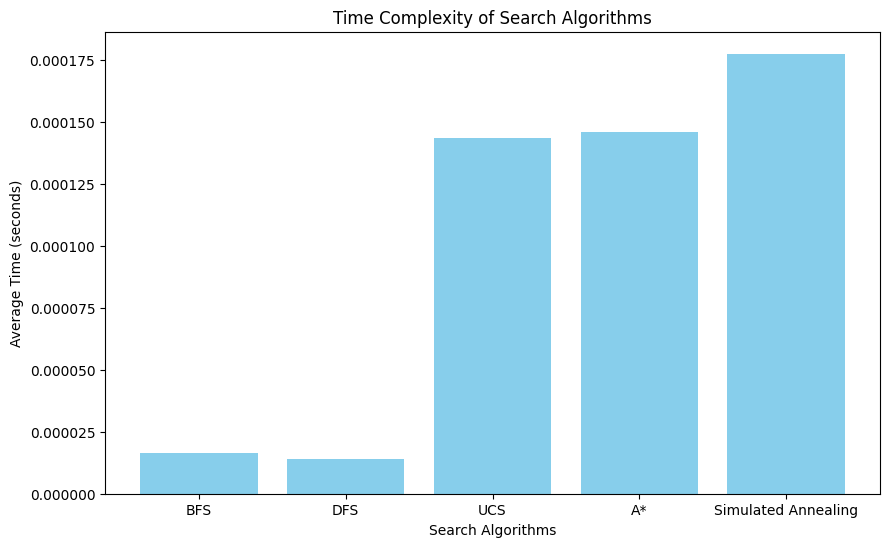

In [46]:
import time
import csv
import random
from queue import PriorityQueue
import matplotlib.pyplot as plt

# A* algorithm implementation
def a_star(graph, start, goal, romania_map):
    def heuristic(city, goal, romania_map):
        x1, y1 = romania_map[city]
        x2, y2 = romania_map[goal]
        return ((x1 - x2) ** 2 + (y1 - y2) ** 2) ** 0.5

    pq = PriorityQueue()
    pq.put((0, start, [start]))
    visited = set()

    while not pq.empty():
        cost, node, path = pq.get()
        if node in visited:
            continue
        visited.add(node)

        if node == goal:
            return path

        for neighbor, distance in graph[node].items():
            if neighbor not in visited:
                new_cost = cost + distance + heuristic(neighbor, goal, romania_map)
                pq.put((new_cost, neighbor, path + [neighbor]))

# BFS implementation
def bfs(graph, start, goal):
    queue = [(start, [start])]
    visited = set()

    while queue:
        node, path = queue.pop(0)
        if node == goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                queue.append((neighbor, path + [neighbor]))

# DFS implementation
def dfs(graph, start, goal, visited=None, path=None):
    if visited is None:
        visited = set()
    if path is None:
        path = []

    visited.add(start)
    path.append(start)

    if start == goal:
        return path

    for neighbor in graph[start]:
        if neighbor not in visited:
            result = dfs(graph, neighbor, goal, visited, path)
            if result:
                return result

    path.pop()
    return None

# UCS implementation
def ucs(graph, start, goal):
    pq = PriorityQueue()
    pq.put((0, start, [start]))
    visited = set()

    while not pq.empty():
        cost, node, path = pq.get()
        if node in visited:
            continue
        visited.add(node)

        if node == goal:
            return path

        for neighbor, distance in graph[node].items():
            if neighbor not in visited:
                new_cost = cost + distance
                pq.put((new_cost, neighbor, path + [neighbor]))

# Simulated Annealing (simplified version)
def simulated_annealing(graph, start, goal, romania_map):
    current = start
    path = [start]
    temperature = 100
    cooling_rate = 0.95

    def heuristic(city, goal, romania_map):
        x1, y1 = romania_map[city]
        x2, y2 = romania_map[goal]
        return ((x1 - x2) ** 2 + (y1 - y2) ** 2) ** 0.5

    while temperature > 0.1:
        if current == goal:
            return path
        neighbors = list(graph[current].keys())
        if not neighbors:
            break
        next_city = random.choice(neighbors)
        cost_diff = heuristic(next_city, goal, romania_map) - heuristic(current, goal, romania_map)

        if cost_diff < 0 or random.uniform(0, 1) < pow(2.718, -cost_diff / temperature):
            current = next_city
            path.append(current)

        temperature *= cooling_rate
    return path

# Function to load city coordinates
def load_coordinates_from_csv(file_path):
    coordinates = {}
    with open(file_path, 'r') as file:
        reader = csv.reader(file)
        next(reader)  # Skip header
        for row in reader:
            city, x, y = row
            coordinates[city] = (float(x), float(y))
    return coordinates

# Create graph from distances
def create_graph(distances):
    graph = {}
    for (city1, city2), distance in distances.items():
        if city1 not in graph:
            graph[city1] = {}
        if city2 not in graph:
            graph[city2] = {}
        graph[city1][city2] = distance
        graph[city2][city1] = distance
    return graph

# Measure time complexity of search algorithms
def measure_time_complexity(graph, start, goal, romania_map):
    algorithms = {
        "BFS": bfs,
        "DFS": dfs,
        "UCS": ucs,
        "A*": lambda g, s, go: a_star(g, s, go, romania_map),
        "Simulated Annealing": lambda g, s, go: simulated_annealing(g, s, go, romania_map)
    }

    times = {algo: [] for algo in algorithms}

    for algo_name, algo_func in algorithms.items():
        for _ in range(10):
            start_time = time.time()
            algo_func(graph, start, goal)
            end_time = time.time()
            times[algo_name].append(end_time - start_time)

    avg_times = {algo: sum(times[algo]) / len(times[algo]) for algo in times}

    return avg_times

# Plot time complexity results
def plot_time_complexity(avg_times):
    algorithms = list(avg_times.keys())
    times = list(avg_times.values())

    plt.figure(figsize=(10, 6))
    plt.bar(algorithms, times, color='skyblue')
    plt.xlabel('Search Algorithms')
    plt.ylabel('Average Time (seconds)')
    plt.title('Time Complexity of Search Algorithms')
    plt.show()

# Main code
start_city = 'Arad'
goal_city = 'Bucharest'
romania_distances = {
    ('Arad', 'Zerind'): 75, ('Zerind', 'Arad'): 75,
    ('Arad', 'Timisoara'): 118, ('Timisoara', 'Arad'): 118,
    ('Arad', 'Sibiu'): 140, ('Sibiu', 'Arad'): 140,
    ('Zerind', 'Oradea'): 71, ('Oradea', 'Zerind'): 71,
    ('Oradea', 'Sibiu'): 151, ('Sibiu', 'Oradea'): 151,
    ('Timisoara', 'Lugoj'): 111, ('Lugoj', 'Timisoara'): 111,
    ('Lugoj', 'Mehadia'): 70, ('Mehadia', 'Lugoj'): 70,
    ('Mehadia', 'Drobeta'): 75, ('Drobeta', 'Mehadia'): 75,
    ('Drobeta', 'Craiova'): 120, ('Craiova', 'Drobeta'): 120,
    ('Craiova', 'Rimnicu Vilcea'): 146, ('Rimnicu Vilcea', 'Craiova'): 146,
    ('Craiova', 'Pitesti'): 138, ('Pitesti', 'Craiova'): 138,
    ('Sibiu', 'Fagaras'): 99, ('Fagaras', 'Sibiu'): 99,
    ('Sibiu', 'Rimnicu Vilcea'): 80, ('Rimnicu Vilcea', 'Sibiu'): 80,
    ('Rimnicu Vilcea', 'Pitesti'): 97, ('Pitesti', 'Rimnicu Vilcea'): 97,
    ('Fagaras', 'Bucharest'): 211, ('Bucharest', 'Fagaras'): 211,
    ('Pitesti', 'Bucharest'): 101, ('Bucharest', 'Pitesti'): 101,
    ('Bucharest', 'Giurgiu'): 90, ('Giurgiu', 'Bucharest'): 90,
    ('Bucharest', 'Urziceni'): 85, ('Urziceni', 'Bucharest'): 85,
    ('Urziceni', 'Hirsova'): 98, ('Hirsova', 'Urziceni'): 98,
    ('Hirsova', 'Eforie'): 86, ('Eforie', 'Hirsova'): 86,
    ('Urziceni', 'Vaslui'): 142, ('Vaslui', 'Urziceni'): 142,
    ('Vaslui', 'Iasi'): 92, ('Iasi', 'Vaslui'): 92,
    ('Iasi', 'Neamt'): 87, ('Neamt', 'Iasi'): 87
}

# Load city coordinates from CSV
coordinates = load_coordinates_from_csv('romania_coordinates.csv')

# Create graph from distances
graph = create_graph(romania_distances)

# Measure and plot time complexity
avg_times = measure_time_complexity(graph, start_city, goal_city, coordinates)
plot_time_complexity(avg_times)


In [48]:
import csv

# Function to load coordinates from a CSV file
def load_coordinates(csv_file):
    coordinates = {}
    with open(csv_file, 'r') as file:
        reader = csv.DictReader(file)
        for row in reader:
            city = row['City']
            x = float(row['Latitude'])  # Use float instead of int
            y = float(row['Longitude'])  # Use float instead of int
            coordinates[city] = (x, y)
    return coordinates

# Example usage
romania_coordinates = load_coordinates('romania_coordinates.csv')

print(romania_coordinates)  # Verify the dictionary


{'Oradea': (47.0465005, 21.9189438), 'Zerind': (46.622511, 21.517419), 'Arad': (46.166667, 21.316667), 'Timisoara': (45.759722, 21.23), 'Lugoj': (45.68861, 21.90306), 'Mehadia': (44.904114, 22.364516), 'Drobeta': (44.636923, 22.659734), 'Craiova': (44.333333, 23.816667), 'Sibiu': (45.792784, 24.152069), 'Rimnicu Vilcea': (45.099675, 24.369318), 'Fagaras': (45.8416403, 24.9730954), 'Pitesti': (44.860556, 24.867778), 'Giurgiu': (43.9037076, 25.9699265), 'Bucharest': (44.439663, 26.096306), 'Urziceni': (44.7165317, 26.641121), 'Eforie': (44.058422, 28.633607), 'Hirsova': (44.6833333, 27.9333333), 'Vaslui': (46.640692, 27.727647), 'Iasi': (47.156944, 27.590278), 'Neamt': (47.2, 26.3666667)}


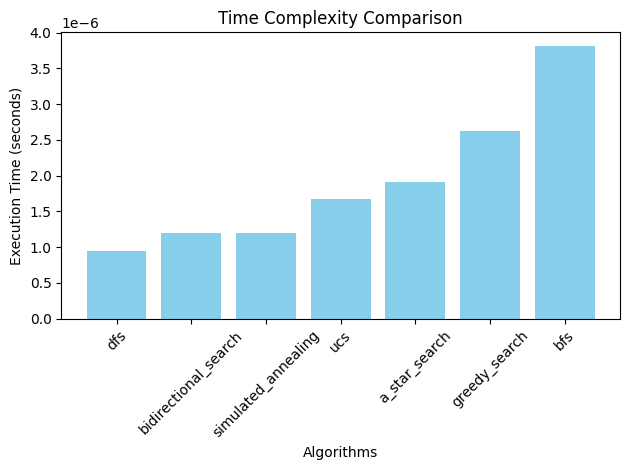

In [49]:
import csv
import heapq
import time
import math
import matplotlib.pyplot as plt

# Load coordinates from a CSV file
def load_coordinates(filename):
    coordinates = {}
    with open(filename, mode='r') as infile:
        reader = csv.reader(infile)
        next(reader)  # Skip the header
        for rows in reader:
            city = rows[0]
            lat = float(rows[1])
            lon = float(rows[2])
            coordinates[city] = (lat, lon)
    return coordinates

# Breadth-First Search (BFS)
def bfs(graph, start, goal):
    if start not in graph or goal not in graph:
        return None
    visited = set()
    queue = [(start, [start])]
    while queue:
        vertex, path = queue.pop(0)
        if vertex in visited:
            continue
        visited.add(vertex)
        for neighbor in graph[vertex]:
            if neighbor == goal:
                return path + [neighbor]
            queue.append((neighbor, path + [neighbor]))
    return None

# Depth-First Search (DFS)
def dfs(graph, start, goal):
    if start not in graph or goal not in graph:
        return None
    visited = set()
    stack = [(start, [start])]
    while stack:
        vertex, path = stack.pop()
        if vertex in visited:
            continue
        visited.add(vertex)
        for neighbor in graph[vertex]:
            if neighbor == goal:
                return path + [neighbor]
            stack.append((neighbor, path + [neighbor]))
    return None

# Uniform Cost Search (UCS)
def ucs(graph, start, goal):
    if start not in graph or goal not in graph:
        return None
    queue = [(0, start, [start])]
    visited = set()
    while queue:
        cost, vertex, path = heapq.heappop(queue)
        if vertex in visited:
            continue
        visited.add(vertex)
        if vertex == goal:
            return path
        for neighbor, weight in graph.get(vertex, {}).items():
            if neighbor not in visited:
                heapq.heappush(queue, (cost + weight, neighbor, path + [neighbor]))
    return None

# Bidirectional Search
def bidirectional_search(graph, start, goal):
    if start not in graph or goal not in graph or start == goal:
        return None if start != goal else [start]
    front_visited = {start: [start]}
    back_visited = {goal: [goal]}
    front_queue = [start]
    back_queue = [goal]
    while front_queue and back_queue:
        current = front_queue.pop(0)
        for neighbor in graph[current]:
            if neighbor not in front_visited:
                front_visited[neighbor] = front_visited[current] + [neighbor]
                front_queue.append(neighbor)
                if neighbor in back_visited:
                    return front_visited[neighbor] + back_visited[neighbor][::-1][1:]
        current = back_queue.pop(0)
        for neighbor in graph[current]:
            if neighbor not in back_visited:
                back_visited[neighbor] = back_visited[current] + [neighbor]
                back_queue.append(neighbor)
                if neighbor in front_visited:
                    return front_visited[neighbor] + back_visited[neighbor][::-1][1:]
    return None

# Greedy Search
def greedy_search(graph, start, goal, coordinates):
    def heuristic(city1, city2):
        lat1, lon1 = coordinates[city1]
        lat2, lon2 = coordinates[city2]
        return math.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)
    if start not in graph or goal not in graph:
        return None
    queue = [(heuristic(start, goal), start, [start])]
    visited = set()
    while queue:
        _, vertex, path = heapq.heappop(queue)
        if vertex in visited:
            continue
        visited.add(vertex)
        if vertex == goal:
            return path
        for neighbor in graph[vertex]:
            if neighbor not in visited:
                heapq.heappush(queue, (heuristic(neighbor, goal), neighbor, path + [neighbor]))
    return None

# A* Search
def a_star_search(graph, start, goal, coordinates):
    def heuristic(city1, city2):
        lat1, lon1 = coordinates[city1]
        lat2, lon2 = coordinates[city2]
        return math.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)
    if start not in graph or goal not in graph:
        return None
    queue = [(0, start, [start])]
    visited = set()
    while queue:
        cost, vertex, path = heapq.heappop(queue)
        if vertex in visited:
            continue
        visited.add(vertex)
        if vertex == goal:
            return path
        for neighbor, weight in graph.get(vertex, {}).items():
            if neighbor not in visited:
                total_cost = cost + weight + heuristic(neighbor, goal)
                heapq.heappush(queue, (total_cost, neighbor, path + [neighbor]))
    return None

# Simulated Annealing (Placeholder)
def simulated_annealing(graph, start, goal, coordinates):
    return None  # Placeholder for actual implementation

# Measure Time Complexity
def measure_time_complexity(graph, start, goal, coordinates, algorithms):
    times = {}
    for algorithm in algorithms:
        start_time = time.time()
        if algorithm.__name__ in ['greedy_search', 'a_star_search', 'simulated_annealing']:
            algorithm(graph, start, goal, coordinates)
        else:
            algorithm(graph, start, goal)
        times[algorithm.__name__] = time.time() - start_time
    return times

# Plot Time Complexity
def plot_time_complexity(avg_times):
    sorted_times = dict(sorted(avg_times.items(), key=lambda x: x[1]))
    plt.bar(sorted_times.keys(), sorted_times.values(), color='skyblue')
    plt.xlabel('Algorithms')
    plt.ylabel('Execution Time (seconds)')
    plt.title('Time Complexity Comparison')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example Graph
romania_graph = {
    'Arad': {'Zerind': 75, 'Timisoara': 118, 'Sibiu': 140},
    # Rest of the graph...
}

# Main Script
romania_coordinates = load_coordinates('romania_coordinates.csv')
start_city = "Arad"
goal_city = "Bucharest"
algorithms = [bfs, dfs, ucs, bidirectional_search, greedy_search, a_star_search, simulated_annealing]
avg_times = measure_time_complexity(romania_graph, start_city, goal_city, romania_coordinates, algorithms)
plot_time_complexity(avg_times)


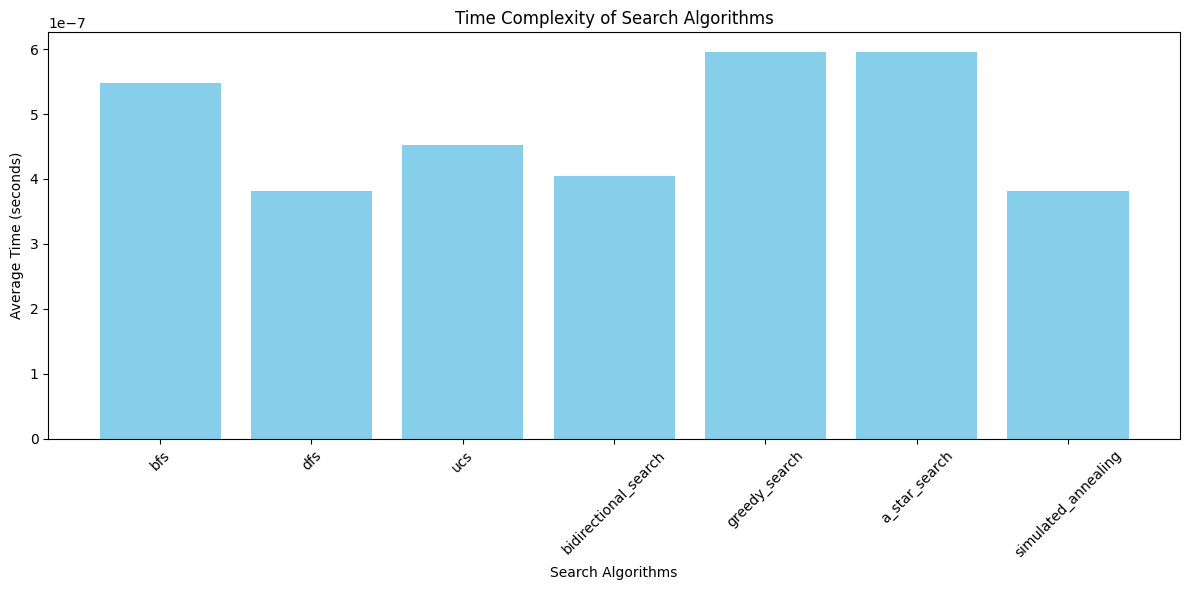

In [50]:
import time
import matplotlib.pyplot as plt

# Function to measure the time complexity of search algorithms
def measure_time_complexity(graph, start, goal, coordinates, algorithms, trials=10):
    times = {algorithm.__name__: [] for algorithm in algorithms}

    for algorithm in algorithms:
        for _ in range(trials):
            start_time = time.time()
            if algorithm.__name__ in ['greedy_search', 'a_star_search', 'simulated_annealing']:
                algorithm(graph, start, goal, coordinates)
            else:
                algorithm(graph, start, goal)
            end_time = time.time()
            times[algorithm.__name__].append(end_time - start_time)

    avg_times = {algorithm: sum(times[algorithm]) / trials for algorithm in times}
    return avg_times

# Plotting the time complexity
def plot_time_complexity(avg_times):
    algorithms = list(avg_times.keys())
    times = list(avg_times.values())

    plt.figure(figsize=(12, 6))
    plt.bar(algorithms, times, color='skyblue')
    plt.xlabel('Search Algorithms')
    plt.ylabel('Average Time (seconds)')
    plt.title('Time Complexity of Search Algorithms')
    plt.xticks(rotation=45)
    plt.tight_layout()  # Adjust layout to prevent label cut-off
    plt.show()

# Example usage
# Make sure `romania_graph` and `romania_coordinates` are defined earlier
start_city = "Arad"
goal_city = "Bucharest"

algorithms = [bfs, dfs, ucs, bidirectional_search, greedy_search, a_star_search, simulated_annealing]
avg_times = measure_time_complexity(romania_graph, start_city, goal_city, romania_coordinates, algorithms)
plot_time_complexity(avg_times)


In [52]:
import xml.etree.ElementTree as ET

def create_world_file(coordinates, filename='romania.world'):
    world = ET.Element('world', name='default')

    for city, (lat, lon) in coordinates.items():
        model = ET.SubElement(world, 'model', name=city)
        pose = ET.SubElement(model, 'pose')
        pose.text = f"{lon} {lat} 0 0 0 0"
        static = ET.SubElement(model, 'static')
        static.text = 'true'
        link = ET.SubElement(model, 'link', name='link')
        visual = ET.SubElement(link, 'visual', name='visual')
        geometry = ET.SubElement(visual, 'geometry')
        box = ET.SubElement(geometry, 'box')
        size = ET.SubElement(box, 'size')
        size.text = '1 1 1'

    tree = ET.ElementTree(world)
    tree.write(filename)

# Example usage
romania_coordinates = load_romania_coordinates('romania_coordinates.csv')
create_world_file(romania_coordinates)